In [19]:
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
df = pd.read_csv("sales_data_sample.csv", encoding='latin1')
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [21]:
df.drop_duplicates(inplace=True)
df.isnull().sum()

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64

In [22]:
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])

In [23]:
df.dtypes

ORDERNUMBER                  int64
QUANTITYORDERED              int64
PRICEEACH                  float64
ORDERLINENUMBER              int64
SALES                      float64
ORDERDATE           datetime64[us]
STATUS                         str
QTR_ID                       int64
MONTH_ID                     int64
YEAR_ID                      int64
PRODUCTLINE                    str
MSRP                         int64
PRODUCTCODE                    str
CUSTOMERNAME                   str
PHONE                          str
ADDRESSLINE1                   str
ADDRESSLINE2                   str
CITY                           str
STATE                          str
POSTALCODE                     str
COUNTRY                        str
TERRITORY                      str
CONTACTLASTNAME                str
CONTACTFIRSTNAME               str
DEALSIZE                       str
dtype: object

In [24]:
df['SALES'] = df['QUANTITYORDERED'] * df['PRICEEACH']  # revenue

In [25]:
monthly_sales = df.groupby('MONTH_ID')['SALES'].sum()
print(monthly_sales)

MONTH_ID
1      659582.29
2      668328.15
3      626186.73
4      560334.46
5      756812.91
6      384743.59
7      420973.34
8      552132.91
9      474900.12
10     919036.70
11    1744682.45
12     523173.14
Name: SALES, dtype: float64


In [26]:
top_products = df.groupby('PRODUCTLINE')['SALES'].sum().sort_values(ascending=False)
print(top_products)

PRODUCTLINE
Classic Cars        2968546.40
Vintage Cars        1644212.05
Motorcycles          971086.29
Trucks and Buses     947355.18
Planes               877942.21
Ships                677940.40
Trains               203804.26
Name: SALES, dtype: float64


In [27]:
top_customers = df.groupby('CUSTOMERNAME')['SALES'].sum().sort_values(ascending=False).head(10)
print(top_customers)

CUSTOMERNAME
Euro Shopping Channel           766195.05
Mini Gifts Distributors Ltd.    530587.19
Australian Collectors, Co.      164575.87
La Rochelle Gifts               153909.82
Muscle Machine Inc              151782.04
Land of Toys Inc.               138798.17
AV Stores, Co.                  136873.25
The Sharp Gifts Warehouse       136383.04
Souveniers And Things Co.       133223.38
Dragon Souveniers, Ltd.         131279.95
Name: SALES, dtype: float64


In [28]:
customer_spending = df.groupby('CUSTOMERNAME')['SALES'].sum()

def segment(x):
    if x > 50000:
        return "High Value"
    elif x > 20000:
        return "Medium Value"
    else:
        return "Low Value"

segments = customer_spending.apply(segment)
print(segments.head())

CUSTOMERNAME
AV Stores, Co.               High Value
Alpha Cognac                 High Value
Amica Models & Co.           High Value
Anna's Decorations, Ltd      High Value
Atelier graphique          Medium Value
Name: SALES, dtype: str


# Monthly Sales Chart

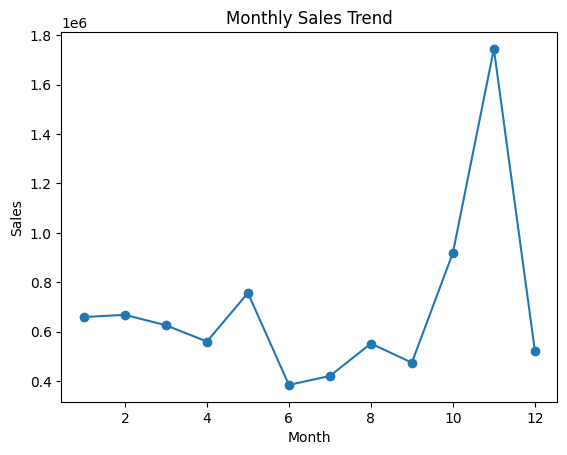

In [29]:
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

# Top Product Chart

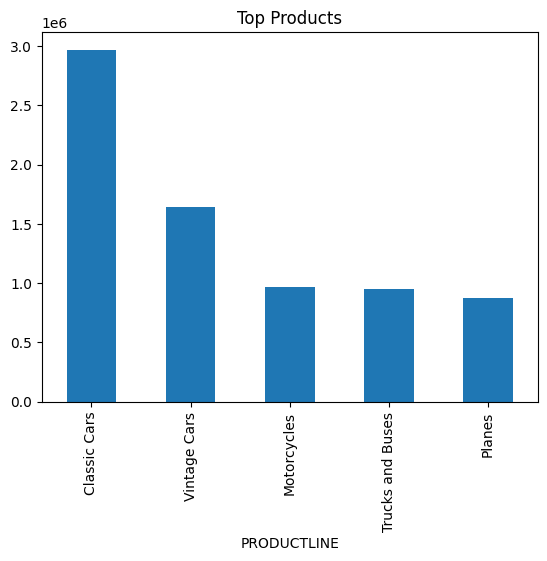

In [30]:
top_products.head(5).plot(kind='bar')
plt.title("Top Products")
plt.show()

# Insights:
# -Certain months show higher sales trends
# -A small group of customers contributes major revenue
# -Some product categories dominate sales

# Monthly Sales Insight

In [31]:
monthly_sales = df.groupby(['YEAR_ID','MONTH_ID'])['SALES'].sum().sort_values(ascending=False)
monthly_sales.head()

YEAR_ID  MONTH_ID
2004     11          894479.18
2003     11          850203.27
         10          466240.57
2004     10          452796.13
         8           386106.59
Name: SALES, dtype: float64

# November 2004 recorded the highest sales, indicating a strong seasonal peak.

# Top Customers Insight

In [32]:
top_customers = df.groupby('CUSTOMERNAME')['SALES'].sum().sort_values(ascending=False)
top_customers.head(10)

CUSTOMERNAME
Euro Shopping Channel           766195.05
Mini Gifts Distributors Ltd.    530587.19
Australian Collectors, Co.      164575.87
La Rochelle Gifts               153909.82
Muscle Machine Inc              151782.04
Land of Toys Inc.               138798.17
AV Stores, Co.                  136873.25
The Sharp Gifts Warehouse       136383.04
Souveniers And Things Co.       133223.38
Dragon Souveniers, Ltd.         131279.95
Name: SALES, dtype: float64

In [33]:
top_10_sum = top_customers.head(10).sum()
total_sales = df['SALES'].sum()

(top_10_sum / total_sales) * 100

np.float64(29.473418488204928)

# The top 10 customers contribute approximately of 29.47% total revenue, showing customer concentration.

# Product Performance Insights

In [34]:
top_products = df.groupby('PRODUCTLINE')['SALES'].sum().sort_values(ascending=False)
top_products

PRODUCTLINE
Classic Cars        2968546.40
Vintage Cars        1644212.05
Motorcycles          971086.29
Trucks and Buses     947355.18
Planes               877942.21
Ships                677940.40
Trains               203804.26
Name: SALES, dtype: float64

# Classic Cars generated the highest revenue, making it the most profitable product category.